In [1]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import LabelEncoder , StandardScaler , label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score, f1_score , roc_curve, auc , roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

# Diabetes Hospital Readmission Prediction

This project uses the Diabetes 130-US Hospitals dataset to predict hospital readmission. The dataset contains patient and hospital-related information that can be used to identify patterns associated with readmission.

In [2]:
path = kagglehub.dataset_download(
    "gigimolashkhia/diabetes-130-us-hospitals-for-years-1999-2008"
)

print("Path to dataset files:", path)

df = pd.read_csv(path + "/diabetic_data.csv")
df.head()

Path to dataset files: C:\Users\Ofogh Rayaneh\.cache\kagglehub\datasets\gigimolashkhia\diabetes-130-us-hospitals-for-years-1999-2008\versions\2


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
missing = df.isin(['?']).sum() + df.isna().sum()
missing_percentage = (missing / len(df)) * 100
missing_summary = pd.DataFrame({ 'Missing Count': missing, 'Missing Percentage': missing_percentage })
missing_summary = missing_summary.sort_values( by='Missing Percentage', ascending=False )
missing_summary

,Missing Count,Missing Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636
encounter_id,0,0.000000


## Data Types and Unique Values

The data types and number of unique values were examined to better understand the structure of the dataset and identify categorical and numerical features.

In [4]:
pd.set_option('display.max_rows', None)
column_info = pd.DataFrame({ 'Column': df.columns, 'Data Type': df.dtypes.astype(str).values, 'Unique Values': [df[col].nunique(dropna=False) for col in df.columns] })
column_info

,Column,Data Type,Unique Values
0,encounter_id,int64,101766
1,patient_nbr,int64,71518
2,race,object,6
3,gender,object,3
4,age,object,10
5,weight,object,10
6,admission_type_id,int64,8
7,discharge_disposition_id,int64,26
8,admission_source_id,int64,17
9,time_in_hospital,int64,14


## Categorical Feature Exploration

Categorical variables were examined to understand their possible values and identify missing or unknown entries represented by `?`.

In [5]:
categorical_columns = df.select_dtypes(include='object').columns

In [6]:
for column in categorical_columns: 
    print(f"\n{'=' * 60}")
    print(f"{column}") 
    print(f"{'=' * 60}")
    print(df[column].value_counts(dropna=False))


race
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

weight
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

payer_code
payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count,

## Data Cleaning

Constant columns and potential identifier columns were identified before removing features that were not useful for the prediction task. Missing values represented by `?` were also standardized as `NaN`.

In [7]:
constant_columns = [ column for column in df.columns
                    if df[column].nunique(dropna=False) <= 1 ]
print("Constant columns:") 
print(constant_columns)
print("\nPotential identifier columns:") 
print(["encounter_id", "patient_nbr"])

Constant columns:
['examide', 'citoglipton']

Potential identifier columns:
['encounter_id', 'patient_nbr']


In [8]:
df_clean = df.copy()

In [9]:
columns_to_drop = [ 'encounter_id', 'patient_nbr', 'examide', 'citoglipton' ]
df_clean = df_clean.drop(columns=columns_to_drop)
print("Removed columns:") 
print(columns_to_drop)
print("\nOriginal shape:", df.shape) 
print("Cleaned shape:", df_clean.shape)

Removed columns:
['encounter_id', 'patient_nbr', 'examide', 'citoglipton']

Original shape: (101766, 50)
Cleaned shape: (101766, 46)


In [10]:
df_clean = df_clean.replace('?' , np.nan)
print("Missing Values have been standardized.")

Missing Values have been standardized.


In [11]:
missing_summary_clean = pd.DataFrame({
    'Missing Count' : df_clean.isna().sum(),
    'Missing Percentage' : df_clean.isna().sum() / len(df_clean) * 100})

In [12]:
missing_summary_clean = missing_summary_clean[
missing_summary_clean['Missing Count'] > 0].sort_values(by ='Missing Percentage' , ascending = False)
missing_summary_clean

,Missing Count,Missing Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [13]:
print(df_clean['weight'].value_counts(dropna=False))

weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64


In [14]:
df_clean = df_clean.drop(columns =['weight'])
print("current dataset shape:" , df_clean.shape)

current dataset shape: (101766, 45)


In [15]:
print(df_clean['max_glu_serum'].value_counts(dropna=False))

max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64


In [16]:
df_clean = df_clean.drop(columns =['max_glu_serum'])
print("current dataset shape:" , df_clean.shape)

current dataset shape: (101766, 44)


In [17]:
print(df_clean['A1Cresult'].value_counts(dropna=False))

A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64


In [18]:
df_clean['A1Cresult'] = df_clean['A1Cresult'].fillna('Not_Measured')
print(df_clean['A1Cresult'].value_counts())

A1Cresult
Not_Measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64


In [19]:
print(df_clean['medical_specialty'].value_counts(dropna=False))
print(df_clean['payer_code'].value_counts(dropna=False))

medical_specialty
NaN                                     49949
InternalMedicine                        14635
Emergency/Trauma                         7565
Family/GeneralPractice                   7440
Cardiology                               5352
Surgery-General                          3099
Nephrology                               1613
Orthopedics                              1400
Orthopedics-Reconstructive               1233
Radiologist                              1140
Pulmonology                               871
Psychiatry                                854
Urology                                   685
ObstetricsandGynecology                   671
Surgery-Cardiovascular/Thoracic           652
Gastroenterology                          564
Surgery-Vascular                          533
Surgery-Neuro                             468
PhysicalMedicineandRehabilitation         391
Oncology                                  348
Pediatrics                                254
Hematology/Oncol

In [20]:
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Not_Specified')
df_clean['payer_code'] = df_clean['payer_code'].fillna('Not_Specified')

In [21]:
print("Remaining missing values:" , "\n" , df_clean.isna().sum()[df_clean.isna().sum() >0])

Remaining missing values: 
 race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64


In [22]:
print(df_clean['race'].value_counts(dropna=False))
print(df_clean['diag_1'].value_counts(dropna=False))
print(df_clean['diag_2'].value_counts(dropna=False))
print(df_clean['diag_3'].value_counts(dropna=False))

race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
diag_1
428       6862
414       6581
786       4016
410       3614
486       3508
427       2766
491       2275
715       2151
682       2042
434       2028
780       2019
996       1967
276       1889
38        1688
250.8     1680
599       1595
584       1520
V57       1207
250.6     1183
518       1115
820       1082
577       1057
493       1056
435       1016
562        989
574        965
296        896
560        876
250.7      871
250.13     851
440        840
433        789
998        784
722        771
250.02     675
578        663
250.11     625
507        610
789        561
453        546
530        531
8          515
403        513
535        450
415        449
402        449
295        447
724        440
458        426
162        425
997        424
250.12     417
250.82     412
278        379
73

In [23]:
df_clean['race'] = df_clean['race'].fillna('Not_Specified')
print(df_clean['race'].value_counts())

race
Caucasian          76099
AfricanAmerican    19210
Not_Specified       2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


In [24]:
df_clean['diag_1'] = df_clean['diag_1'].fillna('Not_Specified')
print(df_clean['diag_1'].isna().sum())

0


In [25]:
df_clean['diag_2'] = df_clean['diag_2'].fillna('Not_Specified')
print(df_clean['diag_2'].isna().sum())

0


In [26]:
df_clean['diag_3'] = df_clean['diag_3'].fillna('Not_Specified')
print(df_clean['diag_3'].isna().sum())

0


In [27]:
missing_final = df_clean.isna().sum()
print("Total missing values" , missing_final.sum())
print("Columns with missing values:", "\n" , missing_final > 0)

Total missing values 0
Columns with missing values: 
 race                        False
gender                      False
age                         False
admission_type_id           False
discharge_disposition_id    False
admission_source_id         False
time_in_hospital            False
payer_code                  False
medical_specialty           False
num_lab_procedures          False
num_procedures              False
num_medications             False
number_outpatient           False
number_emergency            False
number_inpatient            False
diag_1                      False
diag_2                      False
diag_3                      False
number_diagnoses            False
A1Cresult                   False
metformin                   False
repaglinide                 False
nateglinide                 False
chlorpropamide              False
glimepiride                 False
acetohexamide               False
glipizide                   False
glyburide                   

## Data Quality Check

In [28]:
duplicate_count = df_clean.duplicated().sum()
print("Number of duplicate rows:" , duplicate_count)

Number of duplicate rows: 0


In [29]:
print(df_clean.dtypes)

race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
glyburide                   object
tolbutamide         

## Data Preprocessing

In [30]:
numeric_columns = df_clean.select_dtypes(include =['int64']).columns
print(df_clean[numeric_columns].describe())

       admission_type_id  discharge_disposition_id  admission_source_id  \
count      101766.000000             101766.000000        101766.000000   
mean            2.024006                  3.715642             5.754437   
std             1.445403                  5.280166             4.064081   
min             1.000000                  1.000000             1.000000   
25%             1.000000                  1.000000             1.000000   
50%             1.000000                  1.000000             7.000000   
75%             3.000000                  4.000000             7.000000   
max             8.000000                 28.000000            25.000000   

       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count     101766.000000       101766.000000   101766.000000    101766.000000   
mean           4.395987           43.095641        1.339730        16.021844   
std            2.985108           19.674362        1.705807         8.127566   
min 

In [31]:
for column in numeric_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df_clean[column] < lower_bound) | 
                (df_clean[column] > upper_bound)).sum()
    print(column , ":" , outliers)

admission_type_id : 341
discharge_disposition_id : 9818
admission_source_id : 6956
time_in_hospital : 2252
num_lab_procedures : 143
num_procedures : 4954
num_medications : 2557
number_outpatient : 16739
number_emergency : 11383
number_inpatient : 7049
number_diagnoses : 281


## Categorical Encoding

In [32]:
categorical_columns = df_clean.select_dtypes(include =['object']).columns
print("Categorical Columns:", categorical_columns)

Categorical Columns: Index(['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1',
       'diag_2', 'diag_3', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [33]:
x= df_clean.drop(columns=['readmitted'])
y= df_clean['readmitted']

print("x shape:" , x.shape)
print("y shape:" , y.shape)

x shape: (101766, 43)
y shape: (101766,)


In [34]:
print(x.select_dtypes(include =['object']).columns)

Index(['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1',
       'diag_2', 'diag_3', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object')


In [35]:
print(x['age'].value_counts())

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64


In [36]:
age_mapping = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}

x['age'] = x['age'].map(age_mapping)

print(x['age'].value_counts().sort_index())

age
5       161
15      691
25     1657
35     3775
45     9685
55    17256
65    22483
75    26068
85    17197
95     2793
Name: count, dtype: int64


In [37]:
print(x['gender'].value_counts())

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [38]:
gender_mapping = {
    'Female': 0,
    'Male': 1,
    'Unknown/Invalid': 2
}

x['gender'] = x['gender'].map(gender_mapping)

print(x['gender'].value_counts())

gender
0    54708
1    47055
2        3
Name: count, dtype: int64


In [39]:
print(x['race'].value_counts())

race
Caucasian          76099
AfricanAmerican    19210
Not_Specified       2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


In [40]:
race_mapping = {
    'Caucasian': 0,
    'AfricanAmerican': 1,
    'Hispanic': 2,
    'Other': 3,
    'Asian': 4,
    'Not_Specified': 5
}

x['race'] = x['race'].map(race_mapping)

print(x['race'].value_counts())

race
0    76099
1    19210
5     2273
2     2037
3     1506
4      641
Name: count, dtype: int64


In [41]:
print(x['A1Cresult'].value_counts())

A1Cresult
Not_Measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64


In [42]:
A1Cresult_mapping = {
    'Not_Measured' : 0,
    '>8' : 1,
    'Norm' : 2,
    '>7' :3
}
x['A1Cresult'] = x['A1Cresult'].map(A1Cresult_mapping)

print(x['A1Cresult'].value_counts())

A1Cresult
0    84748
1     8216
2     4990
3     3812
Name: count, dtype: int64


In [43]:
print(x['payer_code'].value_counts())

payer_code
Not_Specified    40256
MC               32439
HM                6274
SP                5007
BC                4655
MD                3532
CP                2533
UN                2448
CM                1937
OG                1033
PO                 592
DM                 549
CH                 146
WC                 135
OT                  95
MP                  79
SI                  55
FR                   1
Name: count, dtype: int64


In [44]:
payer_mapping = {
    'Not_Specified': 0,
    'MC': 1,
    'HM': 2,
    'SP': 3,
    'BC': 4,
    'MD': 5,
    'CP': 6,
    'UN': 7,
    'CM': 8,
    'OG': 9,
    'PO': 10,
    'DM': 11,
    'CH': 12,
    'WC': 13,
    'OT': 14,
    'MP': 15,
    'SI': 16,
    'FR': 17
}

x['payer_code'] = x['payer_code'].map(payer_mapping)

print(x['payer_code'].value_counts())

payer_code
0     40256
1     32439
2      6274
3      5007
4      4655
5      3532
6      2533
7      2448
8      1937
9      1033
10      592
11      549
12      146
13      135
14       95
15       79
16       55
17        1
Name: count, dtype: int64


In [45]:
print(x['medical_specialty'].value_counts())

medical_specialty
Not_Specified                           49949
InternalMedicine                        14635
Emergency/Trauma                         7565
Family/GeneralPractice                   7440
Cardiology                               5352
Surgery-General                          3099
Nephrology                               1613
Orthopedics                              1400
Orthopedics-Reconstructive               1233
Radiologist                              1140
Pulmonology                               871
Psychiatry                                854
Urology                                   685
ObstetricsandGynecology                   671
Surgery-Cardiovascular/Thoracic           652
Gastroenterology                          564
Surgery-Vascular                          533
Surgery-Neuro                             468
PhysicalMedicineandRehabilitation         391
Oncology                                  348
Pediatrics                                254
Hematology/Oncol

In [46]:
specialty_mapping = {
    value: i for i, value in enumerate(x['medical_specialty'].unique())
}

x['medical_specialty'] = x['medical_specialty'].map(specialty_mapping)

print(x['medical_specialty'].value_counts())

medical_specialty
1     49949
2     14635
12     7565
3      7440
4      5352
5      3099
9      1613
6      1400
10     1233
60     1140
13      871
11      854
23      685
16      671
8       652
7       564
51      533
14      468
41      391
33      348
17      254
18      207
26      203
0       159
19      125
22      120
36      109
30      101
31      100
54       98
21       87
56       82
32       58
65       57
28       53
50       45
35       41
52       39
38       38
42       37
59       33
15       25
25       25
58       19
27       19
44       17
61       17
66       12
43       12
46       11
20       11
55       11
34       10
70        8
39        8
45        7
67        7
24        7
71        6
29        4
49        4
40        3
48        3
72        2
37        1
57        1
53        1
62        1
63        1
64        1
68        1
69        1
47        1
Name: count, dtype: int64


In [47]:
medication_mapping = {
    'No': 0,
    'Steady': 1,
    'Up': 2,
    'Down': 3
}

medication_cols = [
    'metformin',
    'repaglinide',
    'nateglinide',
    'chlorpropamide',
    'glimepiride',
    'acetohexamide',
    'glipizide',
    'glyburide',
    'tolbutamide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'miglitol',
    'troglitazone',
    'tolazamide',
    'insulin',
    'glyburide-metformin',
    'glipizide-metformin',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

for col in medication_cols:
    x[col] = x[col].map(medication_mapping)

print(x[medication_cols].head())

   metformin  repaglinide  nateglinide  chlorpropamide  glimepiride  \
0          0            0            0               0            0   
1          0            0            0               0            0   
2          0            0            0               0            0   
3          0            0            0               0            0   
4          0            0            0               0            0   

   acetohexamide  glipizide  glyburide  tolbutamide  pioglitazone  ...  \
0              0          0          0            0             0  ...   
1              0          0          0            0             0  ...   
2              0          1          0            0             0  ...   
3              0          0          0            0             0  ...   
4              0          1          0            0             0  ...   

   acarbose  miglitol  troglitazone  tolazamide  insulin  glyburide-metformin  \
0         0         0             0           0

In [48]:
print(x.select_dtypes(include='object').columns)

Index(['diag_1', 'diag_2', 'diag_3', 'change', 'diabetesMed'], dtype='object')


In [49]:
for col in ['change', 'diabetesMed']:
    print(f'\n{col}:')
    print(x[col].value_counts().head(10))


change:
change
No    54755
Ch    47011
Name: count, dtype: int64

diabetesMed:
diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64


In [50]:
change_mapping = {
    'No':0,
    'Ch': 1
}
diabetesMed_mapping = {
    'No':0,
    'Yes': 1
}
x['change'] = x['change'].map(change_mapping)
x['diabetesMed'] = x['diabetesMed'].map(diabetesMed_mapping)
print(x[['change','diabetesMed']].head())

   change  diabetesMed
0       0            0
1       1            1
2       0            1
3       1            1
4       1            1


In [51]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    print(f'\n{col}:')
    print(x[col].value_counts().head(20))


diag_1:
diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

diag_2:
diag_2
276       6752
428       6662
250       6071
427       5036
401       3736
496       3305
599       3288
403       2823
414       2650
411       2566
250.02    2074
707       1999
585       1871
584       1649
491       1545
250.01    1523
285       1520
780       1491
425       1434
682       1433
Name: count, dtype: int64

diag_3:
diag_3
250              11555
401               8289
276               5175
428               4577
427               3955
414               3664
496               2605
403               2357
585               1992
272               1969
599               1941
Not_Specified     1423
V45               1389
250.02            136

In [52]:
def map_diagnosis(code): 
    if pd.isna(code):
        return 'Unknown'
    code = str(code)

    if code.startswith('V'):
        return 'Supplementary'
    if code.startswith('E'):
        return 'Injury'

    try:
        num = float(code)
    except:
        return 'Unknown'

    if 390 <= num <= 459 or num == 785:
        return 'Circulatory'
    elif 460 <= num <= 519:
        return 'Respiratory'
    elif 520 <= num <= 579:
         return 'Digestive'
    elif 580 <= num <= 629:
        return 'Genitourinary'
    elif 250 <= num < 251:
        return 'Diabetes'
    elif 800 <= num <= 999:
        return 'Injury'
    elif 710 <= num <= 739:
        return 'Musculoskeletal'
    elif 140 <= num <= 239:
        return 'Neoplasms'
    elif 290 <= num <= 319:
        return 'Mental'
    elif 630 <= num <= 679:
        return 'Pregnancy'
    elif 680 <= num <= 709:
        return 'Skin'
    elif 1 <= num <= 139:
        return 'Infectious'
    elif 240 <= num <= 279:
        return 'Endocrine'
    elif 280 <= num <= 289:
        return 'Blood'
    elif 320 <= num <= 359:
        return 'Nervous'
    elif 360 <= num <= 389:
        return 'Sense Organs'
    elif 740 <= num <= 759:
        return 'Congenital'
    elif 760 <= num <= 779:
        return 'Perinatal'
    else:
        return 'Other'
for col in ['diag_1', 'diag_2', 'diag_3']:
    x[col] = x[col].apply(map_diagnosis)
print(x[['diag_1', 'diag_2', 'diag_3']].head())

       diag_1     diag_2         diag_3
0    Diabetes    Unknown        Unknown
1   Endocrine   Diabetes      Endocrine
2   Pregnancy   Diabetes  Supplementary
3  Infectious   Diabetes    Circulatory
4   Neoplasms  Neoplasms       Diabetes


In [53]:
print(x.isna().sum())

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

In [54]:
print(x.describe().T)

                             count       mean        std  min   25%   50%  \
race                      101766.0   0.410068   0.945009  0.0   0.0   0.0   
gender                    101766.0   0.462443   0.498649  0.0   0.0   0.0   
age                       101766.0  65.967022  15.940838  5.0  55.0  65.0   
admission_type_id         101766.0   2.024006   1.445403  1.0   1.0   1.0   
discharge_disposition_id  101766.0   3.715642   5.280166  1.0   1.0   1.0   
admission_source_id       101766.0   5.754437   4.064081  1.0   1.0   7.0   
time_in_hospital          101766.0   4.395987   2.985108  1.0   2.0   4.0   
payer_code                101766.0   1.693031   2.453706  0.0   0.0   1.0   
medical_specialty         101766.0   5.101557   9.524055  0.0   1.0   2.0   
num_lab_procedures        101766.0  43.095641  19.674362  1.0  31.0  44.0   
num_procedures            101766.0   1.339730   1.705807  0.0   0.0   1.0   
num_medications           101766.0  16.021844   8.127566  1.0  10.0  15.0   

### Feature Encoding and Train-Test Split

In [55]:
diagnosis_cols = ['diag_1', 'diag_2', 'diag_3']

x = pd.get_dummies(
    x,
    columns = diagnosis_cols,
    dtype = int
)
print(x.shape)

(101766, 100)


In [56]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 123,
    stratify=y
)
print("x_train:" , x_train.shape)
print("x_test:" , x_test.shape)
print("y_train:" , y_train.shape)
print("y_test:" , y_test.shape)

x_train: (81412, 100)
x_test: (20354, 100)
y_train: (81412,)
y_test: (20354,)


In [57]:
print(y.value_counts())
print(y.value_counts(normalize=True))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64


### Target Encoding and Feature Scaling

In [58]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", sorted(set(y_encoded)))

Classes: ['<30' '>30' 'NO']
Encoded classes: [0, 1, 2]


In [59]:
y_train = label_encoder.transform(y_train)
y_test = label_encoder.transform(y_test)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

y_train: (81412,)
y_test: (20354,)


In [60]:
print("Missing values in X_train:", x_train.isna().sum().sum())
print("Missing values in X_test:", x_test.isna().sum().sum())
print("Missing values in y_train:", pd.isna(y_train).sum())
print("Missing values in y_test:", pd.isna(y_test).sum())

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


In [61]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train_scaled:", x_train_scaled.shape)
print("x_test_scaled:", x_test_scaled.shape)

x_train_scaled: (81412, 100)
x_test_scaled: (20354, 100)


## Model Training and Evaluation

In [62]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train_scaled , y_train)
y_pred_logistic = logistic_model.predict(x_test_scaled)
print("Logistic Regression Completed")

Logistic Regression Completed


In [63]:
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=label_encoder.classes_
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

              precision    recall  f1-score   support

         <30       0.41      0.01      0.02      2272
         >30       0.51      0.26      0.34      7109
          NO       0.59      0.89      0.71     10973

    accuracy                           0.57     20354
   macro avg       0.50      0.39      0.36     20354
weighted avg       0.54      0.57      0.51     20354

Confusion Matrix:
[[  26  642 1604]
 [  22 1848 5239]
 [  15 1138 9820]]


In [64]:
tree_model = DecisionTreeClassifier(
    random_state=123
)
tree_model.fit(x_train, y_train)
y_pred_tree = tree_model.predict(x_test)
print("Decision Tree completed.")

Decision Tree completed.


In [65]:
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=label_encoder.classes_
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

              precision    recall  f1-score   support

         <30       0.15      0.15      0.15      2272
         >30       0.40      0.41      0.40      7109
          NO       0.60      0.60      0.60     10973

    accuracy                           0.48     20354
   macro avg       0.38      0.38      0.38     20354
weighted avg       0.48      0.48      0.48     20354

Confusion Matrix:
[[ 337  898 1037]
 [ 857 2888 3364]
 [1041 3378 6554]]


In [66]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=123,
    n_jobs=-1
)
rf_model.fit(x_train_scaled, y_train)
y_pred_rf = rf_model.predict(x_test_scaled)
print("Random Forest completed.")

Random Forest completed.


In [67]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

         <30       0.57      0.02      0.03      2272
         >30       0.50      0.38      0.43      7109
          NO       0.61      0.83      0.71     10973

    accuracy                           0.58     20354
   macro avg       0.56      0.41      0.39     20354
weighted avg       0.57      0.58      0.54     20354

Confusion Matrix:
[[  36  852 1384]
 [  24 2710 4375]
 [   3 1831 9139]]


In [68]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=123,
    n_jobs=-1
)
xgb_model.fit(x_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(x_test_scaled)
print("XGBoost completed.")

XGBoost completed.


In [69]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         <30       0.53      0.03      0.06      2272
         >30       0.52      0.38      0.44      7109
          NO       0.62      0.85      0.72     10973

    accuracy                           0.59     20354
   macro avg       0.56      0.42      0.40     20354
weighted avg       0.57      0.59      0.55     20354

Confusion Matrix:
[[  70  859 1343]
 [  43 2713 4353]
 [  19 1656 9298]]


## Model Comparison

In [70]:
models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}
results = []
for model_name, y_pred in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted")
    })
results_df = pd.DataFrame(results)
print(results_df.round(3))

                 Model  Accuracy  Macro F1  Weighted F1
0  Logistic Regression     0.575     0.359        0.506
1        Decision Tree     0.480     0.384        0.480
2        Random Forest     0.584     0.390        0.536
3              XGBoost     0.594     0.405        0.546


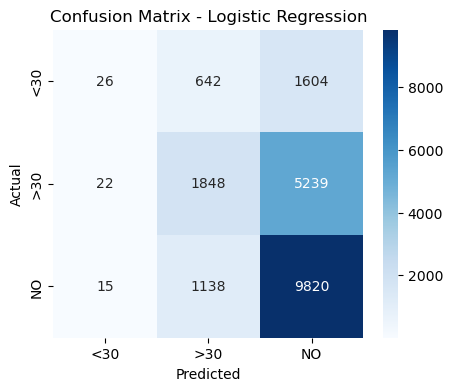

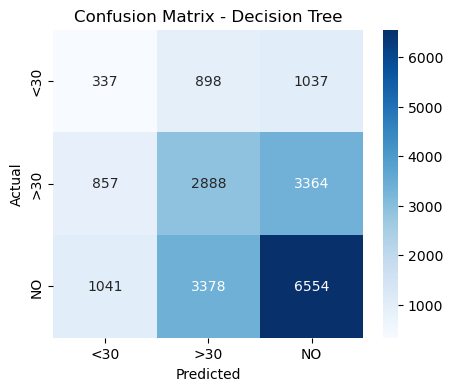

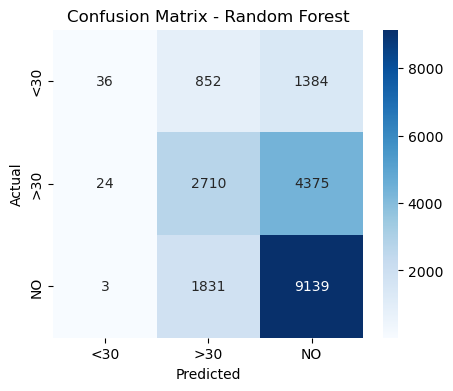

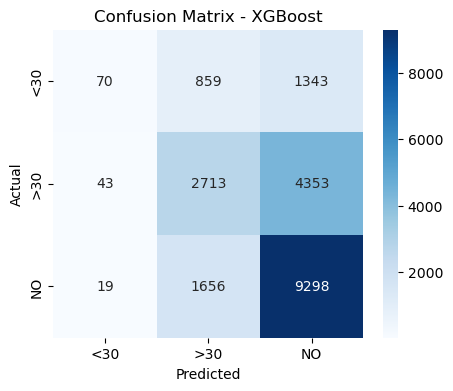

In [71]:
for model_name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

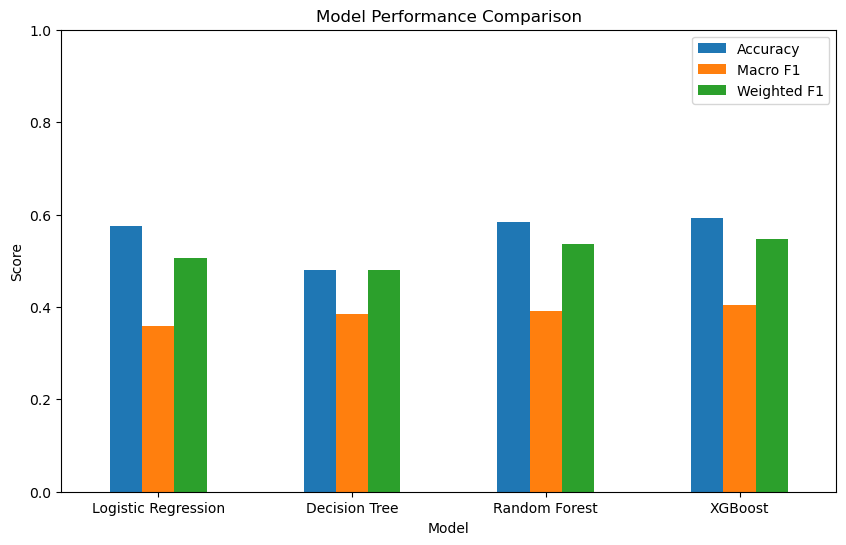

In [72]:
results_df.set_index("Model")[["Accuracy", "Macro F1", "Weighted F1"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

## Feature Importance

In [73]:
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(feature_importance.head(20))

num_lab_procedures          0.106297
num_medications             0.084068
time_in_hospital            0.058425
age                         0.041140
number_inpatient            0.041117
medical_specialty           0.038845
discharge_disposition_id    0.036822
payer_code                  0.036627
num_procedures              0.033547
number_diagnoses            0.032614
insulin                     0.023262
race                        0.019501
admission_type_id           0.019275
gender                      0.015755
admission_source_id         0.015114
A1Cresult                   0.014868
diag_3_Circulatory          0.013860
diag_1_Circulatory          0.013364
diag_2_Circulatory          0.012954
number_outpatient           0.012854
dtype: float64


In [74]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(feature_importance.head(20))

num_lab_procedures          0.082167
num_medications             0.073395
time_in_hospital            0.053504
age                         0.044654
number_inpatient            0.042335
medical_specialty           0.039590
payer_code                  0.037984
discharge_disposition_id    0.037978
number_diagnoses            0.037391
num_procedures              0.035230
insulin                     0.023859
admission_type_id           0.023695
race                        0.020759
admission_source_id         0.019859
gender                      0.018975
number_outpatient           0.017737
A1Cresult                   0.015916
diag_3_Circulatory          0.015240
diag_2_Circulatory          0.014091
number_emergency            0.014014
dtype: float64


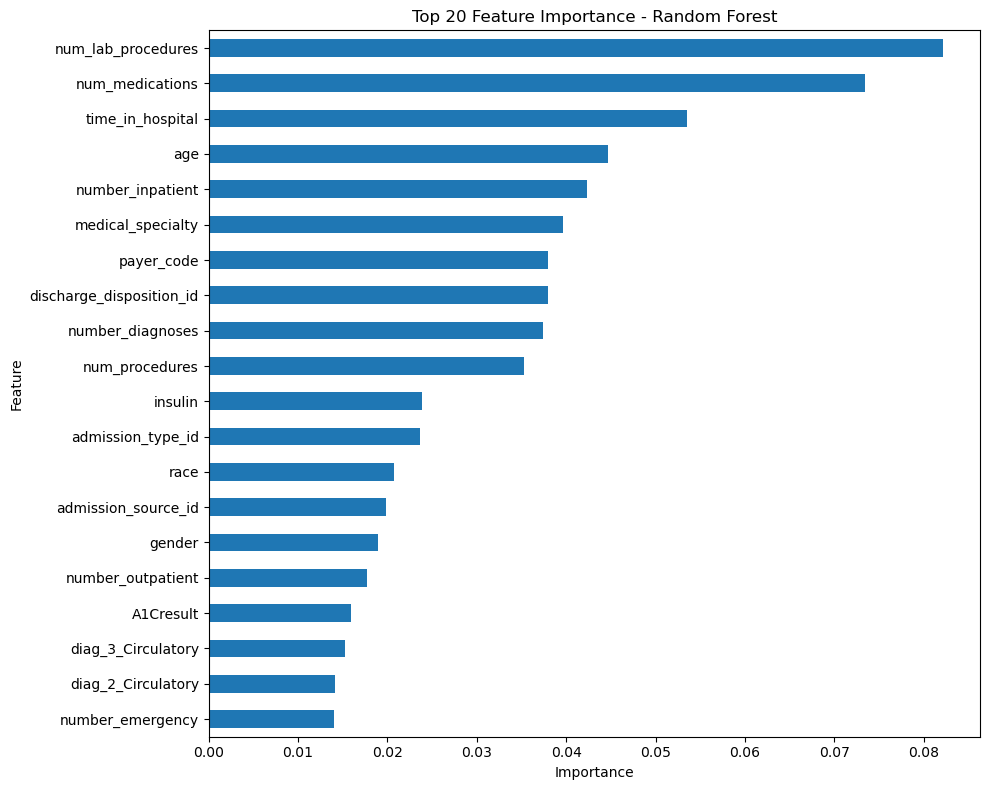

In [75]:
top_features = feature_importance.head(20).sort_values()

plt.figure(figsize=(10, 8))
top_features.plot(kind="barh")

plt.title("Top 20 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## ROC Curve and AUC

In [76]:
y_test_bin = label_binarize(y_test , classes=[0,1,2])

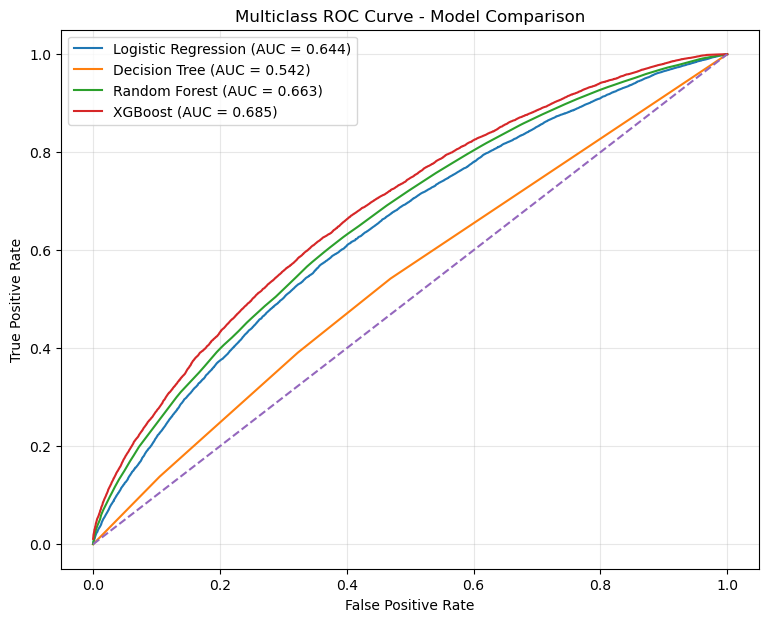

In [77]:
models_proba = {
    "Logistic Regression": logistic_model.predict_proba(x_test_scaled),
    "Decision Tree": tree_model.predict_proba(x_test), 
    "Random Forest": rf_model.predict_proba(x_test_scaled), 
    "XGBoost": xgb_model.predict_proba(x_test_scaled)
}
plt.figure(figsize=(9, 7))

for model_name, y_score in models_proba.items():
    fpr = dict()
    tpr = dict()
    
    for i in range(3):
        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )
    
    all_fpr = np.unique(
        np.concatenate([fpr[i] for i in range(3)])
    )
    
    mean_tpr = np.zeros_like(all_fpr)
    
    for i in range(3):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    
    mean_tpr /= 3
    
    macro_auc = auc(all_fpr, mean_tpr)
    
    plt.plot(
        all_fpr,
        mean_tpr,
        label=f"{model_name} (AUC = {macro_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Macro AUC Comparison

In [78]:
models_proba = {
    "Logistic Regression": logistic_model.predict_proba(x_test_scaled),
    "Decision Tree": tree_model.predict_proba(x_test),
    "Random Forest": rf_model.predict_proba(x_test_scaled),
    "XGBoost": xgb_model.predict_proba(x_test_scaled)
}

auc_results = []

for name, y_prob in models_proba.items():

    macro_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    auc_results.append({
        "Model": name,
        "Macro AUC": macro_auc
    })

final_results = pd.DataFrame(auc_results)

print(final_results.round(3))

                 Model  Macro AUC
0  Logistic Regression      0.644
1        Decision Tree      0.542
2        Random Forest      0.663
3              XGBoost      0.685


## Handling Class Imbalance

In [79]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights

array([2.98704825, 0.95433019, 0.61828925])

In [80]:
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    random_state=123,
    n_jobs=1,
    class_weight="balanced"
)

rf_weighted.fit(x_train_scaled, y_train)

y_pred_rf_weighted = rf_weighted.predict(x_test_scaled)

In [81]:
print(classification_report(
    y_test,
    y_pred_rf_weighted,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         <30       0.51      0.02      0.03      2272
         >30       0.51      0.37      0.43      7109
          NO       0.61      0.84      0.71     10973

    accuracy                           0.59     20354
   macro avg       0.54      0.41      0.39     20354
weighted avg       0.56      0.59      0.54     20354



In [82]:
logistic_weighted = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic_weighted.fit(x_train_scaled, y_train)

y_pred_logistic_weighted = logistic_weighted.predict(x_test_scaled)

In [83]:
print(classification_report(
    y_test,
    y_pred_logistic_weighted ,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         <30       0.17      0.36      0.24      2272
         >30       0.46      0.34      0.39      7109
          NO       0.65      0.61      0.63     10973

    accuracy                           0.49     20354
   macro avg       0.43      0.44      0.42     20354
weighted avg       0.53      0.49      0.50     20354



In [84]:
weighted_results = {
    "Logistic Regression (Balanced)": y_pred_logistic_weighted,
    "Random Forest (Balanced)": y_pred_rf_weighted
}

for model_name, y_pred in weighted_results.items():
    print(f"\n{model_name}")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))


Logistic Regression (Balanced)
              precision    recall  f1-score   support

         <30       0.17      0.36      0.24      2272
         >30       0.46      0.34      0.39      7109
          NO       0.65      0.61      0.63     10973

    accuracy                           0.49     20354
   macro avg       0.43      0.44      0.42     20354
weighted avg       0.53      0.49      0.50     20354


Random Forest (Balanced)
              precision    recall  f1-score   support

         <30       0.51      0.02      0.03      2272
         >30       0.51      0.37      0.43      7109
          NO       0.61      0.84      0.71     10973

    accuracy                           0.59     20354
   macro avg       0.54      0.41      0.39     20354
weighted avg       0.56      0.59      0.54     20354



## Hyperparameter Tuning

In [85]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

In [86]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=123,
        n_jobs=1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=1
)

grid_search.fit(x_train_scaled, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=1, random_state=123),
             n_jobs=1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1_macro')

In [87]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best Macro F1:
0.3877270618130429


In [88]:
best_rf = grid_search.best_estimator_

y_pred_best_rf = best_rf.predict(x_test_scaled)

print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         <30       0.57      0.02      0.03      2272
         >30       0.50      0.38      0.43      7109
          NO       0.61      0.83      0.71     10973

    accuracy                           0.58     20354
   macro avg       0.56      0.41      0.39     20354
weighted avg       0.57      0.58      0.54     20354



## Custom Class Weights

In [89]:
custom_weights = {
    0: 5,
    1: 1,
    2: 0.5
}

In [90]:
rf_custom = RandomForestClassifier(
    n_estimators=100,
    random_state=123,
    n_jobs=-1,
    class_weight=custom_weights
)

rf_custom.fit(x_train_scaled, y_train)

y_pred_rf_custom = rf_custom.predict(x_test_scaled)

In [91]:
print(classification_report(
    y_test,
    y_pred_rf_custom,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         <30       0.44      0.02      0.04      2272
         >30       0.51      0.35      0.42      7109
          NO       0.61      0.85      0.71     10973

    accuracy                           0.58     20354
   macro avg       0.52      0.41      0.39     20354
weighted avg       0.56      0.58      0.53     20354



## Weighted XGBoost

In [92]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

weight_dict = dict(zip(classes, class_weights))

In [93]:
sample_weights = np.array([
    weight_dict[class_label]
    for class_label in y_train
])

print("Class weights:", weight_dict)

Class weights: {0: 2.9870482480278846, 1: 0.9543301917756835, 2: 0.6182892468463542}


In [94]:
xgb_weighted = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=123,
    n_jobs=-1
)

xgb_weighted.fit(
    x_train_scaled,
    y_train,
    sample_weight=sample_weights
)

y_pred_xgb_weighted = xgb_weighted.predict(x_test_scaled)

In [95]:
print(classification_report(
    y_test,
    y_pred_xgb_weighted,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         <30       0.20      0.40      0.26      2272
         >30       0.48      0.43      0.45      7109
          NO       0.69      0.59      0.64     10973

    accuracy                           0.51     20354
   macro avg       0.46      0.47      0.45     20354
weighted avg       0.56      0.51      0.53     20354



## XGBoost Hyperparameter Tuning

In [96]:
xgb_base = XGBClassifier(
    random_state=123,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1]
}

In [97]:
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_xgb.fit(
    x_train_scaled,
    y_train
)

print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest Macro F1:")
print(grid_xgb.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}

Best Macro F1:
0.40680999139573043


In [98]:
best_xgb = grid_xgb.best_estimator_

y_pred_best_xgb = best_xgb.predict(x_test_scaled)

print(classification_report(
    y_test,
    y_pred_best_xgb,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         <30       0.54      0.04      0.08      2272
         >30       0.52      0.41      0.46      7109
          NO       0.63      0.84      0.72     10973

    accuracy                           0.60     20354
   macro avg       0.56      0.43      0.42     20354
weighted avg       0.58      0.60      0.55     20354



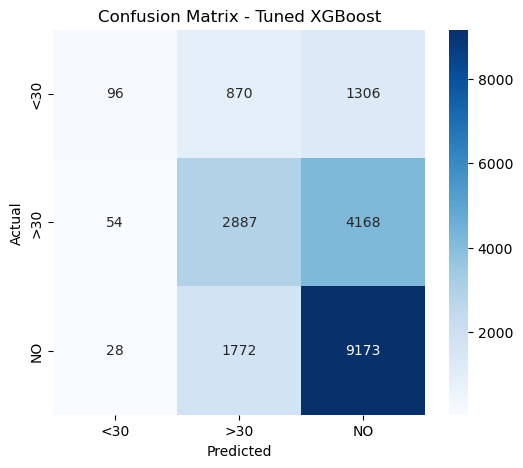

In [99]:
cm = confusion_matrix(y_test, y_pred_best_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## XGBoost Feature Importance

In [100]:
xgb_feature_importance = pd.Series(
    best_xgb.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(xgb_feature_importance.head(20))

number_inpatient            0.115889
discharge_disposition_id    0.039388
diag_1_Pregnancy            0.024433
diabetesMed                 0.021877
admission_source_id         0.020155
diag_1_Neoplasms            0.018267
number_emergency            0.017837
number_diagnoses            0.017777
diag_1_Supplementary        0.016398
number_outpatient           0.014839
diag_2_Skin                 0.013931
payer_code                  0.013085
diag_2_Neoplasms            0.012972
diag_3_Neoplasms            0.012828
diag_2_Pregnancy            0.012539
diag_1_Circulatory          0.011933
age                         0.011898
diag_1_Diabetes             0.011811
diag_1_Mental               0.011600
diag_3_Skin                 0.011502
dtype: float32


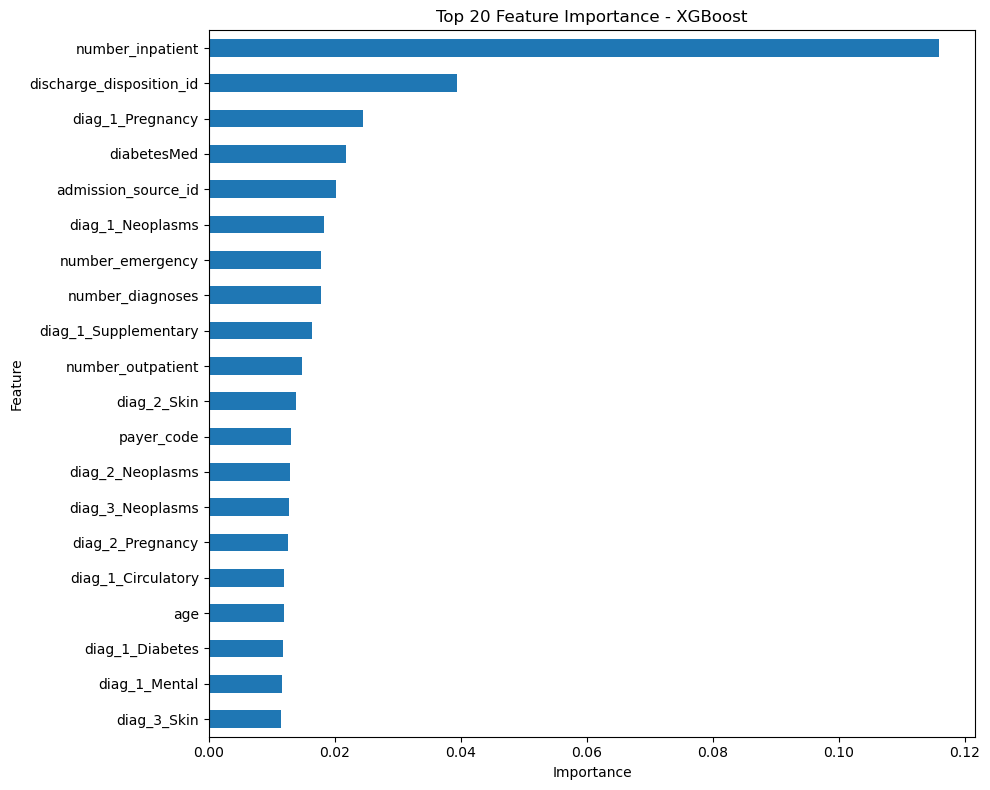

In [101]:
top_xgb_features = xgb_feature_importance.head(20).sort_values()

plt.figure(figsize=(10, 8))

top_xgb_features.plot(kind="barh")

plt.title("Top 20 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Initial Model Comparison

In [102]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [0.575, 0.480, 0.584, 0.594],
    "Macro F1": [0.359, 0.384, 0.390, 0.405],
    "Weighted F1": [0.506, 0.480, 0.536, 0.546],
    "Macro AUC": [0.644, 0.542, 0.663, 0.685]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1,Macro AUC
0,Logistic Regression,0.575,0.359,0.506,0.644
1,Decision Tree,0.480,0.384,0.480,0.542
2,Random Forest,0.584,0.390,0.536,0.663
3,XGBoost,0.594,0.405,0.546,0.685


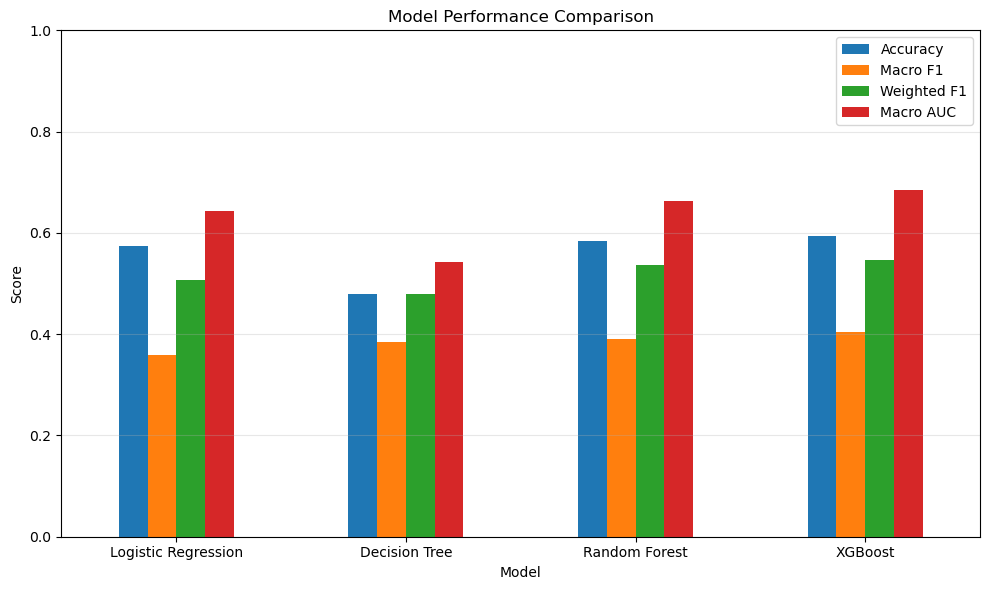

In [103]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Final Model Comparison 

In [104]:
y_prob_best_xgb = best_xgb.predict_proba(x_test_scaled)

macro_auc_best_xgb = roc_auc_score(
    y_test,
    y_prob_best_xgb,
    multi_class="ovr",
    average="macro"
)

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        0.575,
        0.480,
        0.584,
        0.594,
        accuracy_score(y_test, y_pred_best_xgb)
    ],
    "Macro F1": [
        0.359,
        0.384,
        0.390,
        0.405,
        f1_score(y_test, y_pred_best_xgb, average="macro")
    ],
    "Weighted F1": [
        0.506,
        0.480,
        0.536,
        0.546,
        f1_score(y_test, y_pred_best_xgb, average="weighted")
    ],
    "Macro AUC": [
        0.644,
        0.542,
        0.663,
        0.685,
        macro_auc_best_xgb
    ]
})

print(final_comparison.round(3))

                 Model  Accuracy  Macro F1  Weighted F1  Macro AUC
0  Logistic Regression     0.575     0.359        0.506      0.644
1        Decision Tree     0.480     0.384        0.480      0.542
2        Random Forest     0.584     0.390        0.536      0.663
3              XGBoost     0.594     0.405        0.546      0.685
4        Tuned XGBoost     0.597     0.417        0.554      0.687


## Model Explainability with SHAP

In [105]:
x_test_scaled_df = pd.DataFrame(
    x_test_scaled,
    columns=x.columns,
    index=x_test.index
)

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer(x_test_scaled_df)

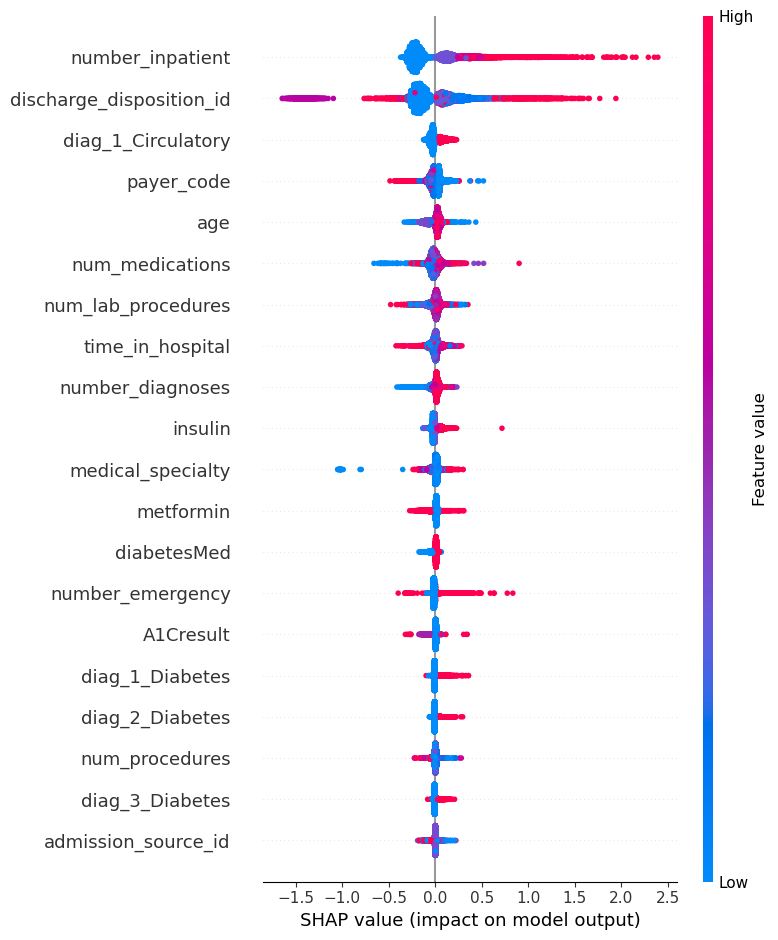

In [106]:
shap_values_class = shap_values.values[:, :, 0]

shap.summary_plot(
    shap_values_class,
    x_test_scaled_df,
    feature_names=x.columns
)

### SHAP Dependence Analysis

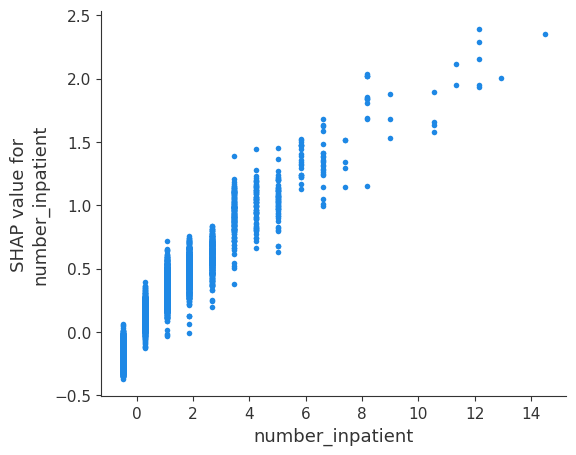

In [107]:
shap_values_class_array = shap_values.values[:, :, 0]

shap.dependence_plot(
    "number_inpatient",
    shap_values_class_array,
    x_test_scaled,
    feature_names=x.columns,
    interaction_index=None
)

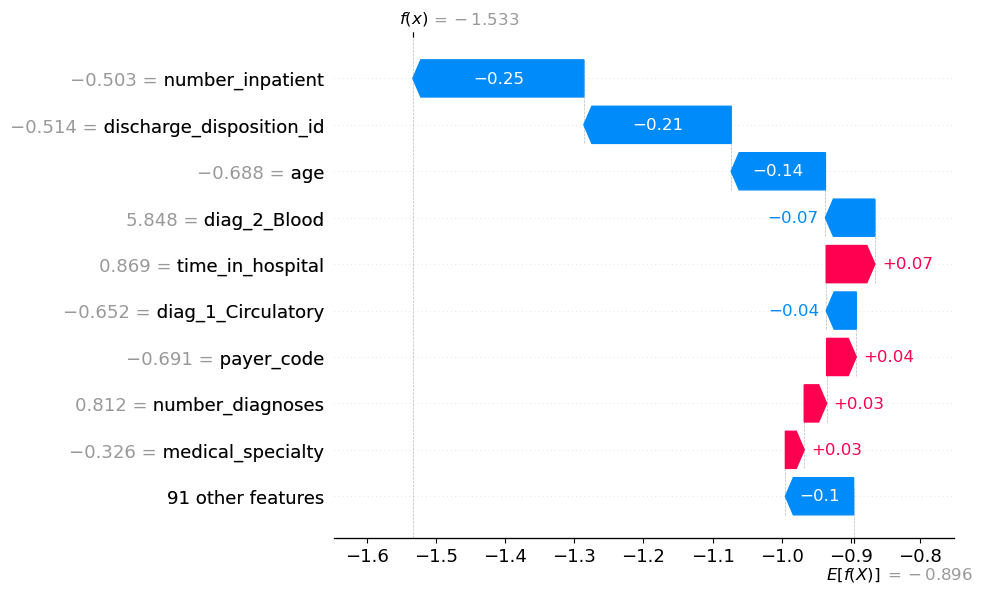

In [108]:
shap.plots.waterfall(
    shap_values[0, :, 0],
    max_display=10
)

### Final Performance Visualization

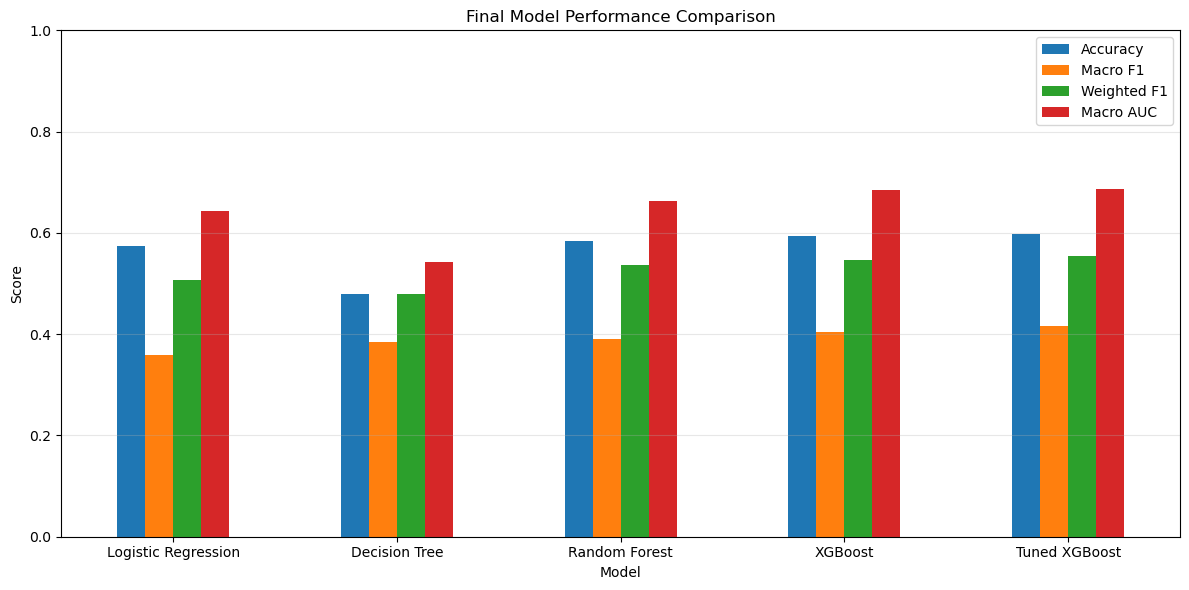

In [109]:
final_comparison.set_index("Model")[
    ["Accuracy", "Macro F1", "Weighted F1", "Macro AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

In this project, I used the Diabetes 130-US Hospitals dataset to predict hospital readmission and compared four machine learning models: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

The initial XGBoost model performed best among the four models, with an Accuracy of 0.594, a Macro F1 score of 0.405, and a Macro AUC of 0.685. I then used class weighting to give more importance to the minority `<30` class. This improved the Macro F1 score to 0.455, although the accuracy dropped to 0.518.

I also tuned the XGBoost hyperparameters. The tuned model achieved an Accuracy of 0.597, a Macro F1 score of 0.417, and a Macro AUC of 0.687. The improvement was relatively small, but the tuned model performed slightly better than the original XGBoost.

The class imbalance was still a major issue, especially for the `<30` class. Even after using class weighting, this class was harder for the models to predict than the other two classes.

Finally, I used SHAP to look at the features that had the strongest influence on the tuned XGBoost model. `number_inpatient`, `discharge_disposition_id`, `age`, and `time_in_hospital` were among the more influential features.

Overall, the models were able to predict some patterns related to readmission, but accurately identifying patients who are readmitted within 30 days remained difficult.